In [58]:
import pandas as pd
import pandas_profiling as pp
import ydata_profiling as yd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [10]:
pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.0.2
    Uninstalling multimethod-2.0.2:
      Successfully uninstalled multimethod-2.0.2
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


In [13]:
customer_df = pd.read_csv('Cust_Segmentation.csv')
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        850 non-null    int64  
 8   Address          850 non-null    object 
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(3), int64(6), object(1)
memory usage: 66.5+ KB


In [5]:
ydata_profiling = yd.ProfileReport(customer_df)
ydata_profiling.to_file('ydata_profiling.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 27.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
cust_cleansed_dt = customer_df.drop(['Customer Id'], axis=1)
cust_cleansed_dt.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0,NBA001,6.3
1,47,1,26,100,4.582,8.218,0,NBA021,12.8
2,33,2,10,57,6.111,5.802,1,NBA013,20.9
3,29,2,4,19,0.681,0.516,0,NBA009,6.3
4,47,1,31,253,9.308,8.908,0,NBA008,7.2


In [17]:
cust_cleansed_dt.select_dtypes(include='object').columns

Index(['Address'], dtype='object')

In [18]:
pd.get_dummies(cust_cleansed_dt['Address'], dtype=int)

,NBA000,NBA001,NBA002,NBA003,NBA004,NBA005,NBA006,NBA007,NBA008,NBA009,...,NBA022,NBA023,NBA024,NBA025,NBA026,NBA027,NBA029,NBA030,NBA031,NBA034
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
846,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
847,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
address_dummies = pd.get_dummies(cust_cleansed_dt['Address'], dtype=int)
cust_cleansed_dt = pd.concat([cust_cleansed_dt, address_dummies], axis=1)
cust_cleansed_dt

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio,NBA000,...,NBA022,NBA023,NBA024,NBA025,NBA026,NBA027,NBA029,NBA030,NBA031,NBA034
0,41,2,6,19,0.124,1.073,0,NBA001,6.3,0,...,0,0,0,0,0,0,0,0,0,0
1,47,1,26,100,4.582,8.218,0,NBA021,12.8,0,...,0,0,0,0,0,0,0,0,0,0
2,33,2,10,57,6.111,5.802,1,NBA013,20.9,0,...,0,0,0,0,0,0,0,0,0,0
3,29,2,4,19,0.681,0.516,0,NBA009,6.3,0,...,0,0,0,0,0,0,0,0,0,0
4,47,1,31,253,9.308,8.908,0,NBA008,7.2,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,27,1,5,26,0.548,1.220,0,NBA007,6.8,0,...,0,0,0,0,0,0,0,0,0,0
846,28,2,7,34,0.359,2.021,0,NBA002,7.0,0,...,0,0,0,0,0,0,0,0,0,0
847,25,4,0,18,2.802,3.210,1,NBA001,33.4,0,...,0,0,0,0,0,0,0,0,0,0
848,32,1,12,28,0.116,0.696,0,NBA012,2.9,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
cust_cleansed_dt.shape

(850, 41)

In [21]:
# Dropping the address columns
cust_cleansed_dt.drop(['Address'], axis=1, inplace=True)
cust_cleansed_dt.shape

(850, 40)

In [23]:
scaler = StandardScaler()

In [24]:
cust_data_scaled = pd.DataFrame(scaler.fit_transform(cust_cleansed_dt), columns=cust_cleansed_dt.columns)
cust_data_scaled.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,NBA000,NBA001,...,NBA022,NBA023,NBA024,NBA025,NBA026,NBA027,NBA029,NBA030,NBA031,NBA034
0,0.742915,0.312122,-0.378790,-0.718459,-0.683811,-0.590489,-0.523797,-0.576525,-0.275589,3.312375,...,-0.103448,-0.114503,-0.068761,-0.103448,-0.109109,-0.068761,-0.03432,-0.03432,-0.048564,-0.03432
1,1.489490,-0.766349,2.573721,1.384325,1.414474,1.512962,-0.523797,0.391387,-0.275589,-0.301898,...,-0.103448,-0.114503,-0.068761,-0.103448,-0.109109,-0.068761,-0.03432,-0.03432,-0.048564,-0.03432
2,-0.252518,0.312122,0.211712,0.268032,2.134141,0.801704,1.909138,1.597554,-0.275589,-0.301898,...,-0.103448,-0.114503,-0.068761,-0.103448,-0.109109,-0.068761,-0.03432,-0.03432,-0.048564,-0.03432
3,-0.750235,0.312122,-0.674041,-0.718459,-0.421643,-0.754467,-0.523797,-0.576525,-0.275589,-0.301898,...,-0.103448,-0.114503,-0.068761,-0.103448,-0.109109,-0.068761,-0.03432,-0.03432,-0.048564,-0.03432
4,1.489490,-0.766349,3.311849,5.356249,3.638900,1.716094,-0.523797,-0.442507,-0.275589,-0.301898,...,-0.103448,-0.114503,-0.068761,-0.103448,-0.109109,-0.068761,-0.03432,-0.03432,-0.048564,-0.03432


In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [27]:
kmeans.fit(cust_data_scaled)

KMeans(n_clusters=3, random_state=42)

In [28]:
kmeans.cluster_centers_ # Centroid of each features of the 3 clusters

array([[ 7.06623561e-01,  2.67186103e-01,  6.60740094e-01,
         1.02953410e+00,  6.08593596e-01,  5.13282878e-01,
         8.44371477e-02,  9.54291017e-02, -2.75589127e-01,
        -3.01898146e-01, -3.01898146e-01, -2.63025455e-01,
        -2.70614714e-01, -2.30832769e-01, -2.50000000e-01,
        -2.25121860e-01, -2.47332839e-01, -2.36433122e-01,
        -2.13331796e-01, -2.10299891e-01, -1.84562348e-01,
        -1.63003216e-01,  5.86657197e+00, -1.47087101e-01,
        -1.63003216e-01, -1.55230105e-01, -1.29407927e-01,
        -1.38508672e-01, -9.74740358e-02, -1.09108945e-01,
        -1.03448276e-01, -1.14502604e-01, -6.87614164e-02,
        -1.03448276e-01, -1.09108945e-01, -6.87614164e-02,
        -3.43199112e-02, -3.43199112e-02, -4.85642931e-02,
        -3.43199112e-02],
       [-5.49009453e-01, -1.01552791e-02, -5.03060500e-01,
        -4.18901211e-01, -3.19943573e-01, -3.62916791e-01,
         1.03444450e-01, -1.17843063e-01,  9.80530326e-02,
         1.14590411e-01,  1.42

In [29]:
# predicting the cluster of each observation
clusters = kmeans.predict(cust_data_scaled)
clusters

array([1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2,
       2, 2, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1,
       2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 0, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2,
       2, 1, 2, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1,
       1, 2, 2, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2,
       0, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 1, 0,
       2, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 2,
       1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 2, 1,
       2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2,

In [31]:
customer_df['Cluster'] = clusters
customer_df.head()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio,Cluster
0,1,41,2,6,19,0.124,1.073,0,NBA001,6.3,1
1,2,47,1,26,100,4.582,8.218,0,NBA021,12.8,2
2,3,33,2,10,57,6.111,5.802,1,NBA013,20.9,2
3,4,29,2,4,19,0.681,0.516,0,NBA009,6.3,1
4,5,47,1,31,253,9.308,8.908,0,NBA008,7.2,2


In [33]:
customer_df.groupby('Cluster').mean(numeric_only=True)

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Cluster,,,,,,,,,
0,482.791667,40.708333,1.958333,13.041667,86.333333,2.869833,4.822292,0.250000,10.812500
1,426.046875,30.617188,1.701172,5.158203,30.539062,0.897070,1.846018,0.257812,9.380273
2,420.229299,41.789809,1.707006,13.780255,69.955414,2.586373,4.955608,0.143312,11.413057


# Cluster Naming
Cluster 1: High Income Category, High Debt, Experienced, High Educated
Cluster 2: Young, Least Experienced, Low Income, Low Debt, Low Educated
Cluster 3: Older, Experienced, Medium Income, Medium Debt, Less Defaulted

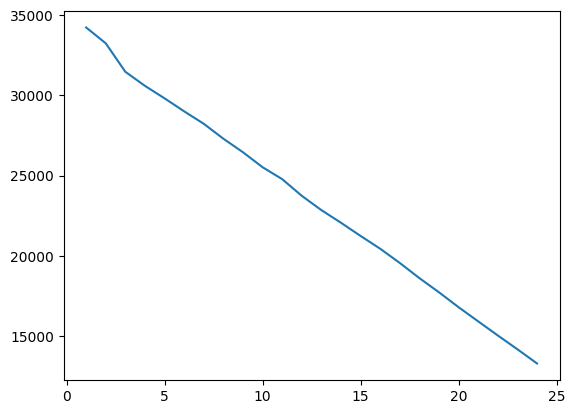

In [36]:
# finding the right number of clusters that are optimal
result = []
for rec in range(1, 25):
  kmeans = KMeans(n_clusters=rec, random_state=42)
  kmeans.fit(cust_data_scaled)
  result.append(kmeans.inertia_)

plt.plot(range(1,25), result)
plt.show()

With above oone hot encoding mehod ELBOW method is NOT predictable.
try removing the one hot encoder of the address and try to find optimal number of clusters

In [46]:
customer_df_addres = customer_df.copy()
customer_df_addres

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio,Cluster
0,1,41,2,6,19,0.124,1.073,0,NBA001,6.3,1
1,2,47,1,26,100,4.582,8.218,0,NBA021,12.8,2
2,3,33,2,10,57,6.111,5.802,1,NBA013,20.9,2
3,4,29,2,4,19,0.681,0.516,0,NBA009,6.3,1
4,5,47,1,31,253,9.308,8.908,0,NBA008,7.2,2
...,...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,0,NBA007,6.8,1
846,847,28,2,7,34,0.359,2.021,0,NBA002,7.0,1
847,848,25,4,0,18,2.802,3.210,1,NBA001,33.4,1
848,849,32,1,12,28,0.116,0.696,0,NBA012,2.9,1


In [47]:
customer_df_addres.drop(['Customer Id', 'Address'], axis= 1,inplace=True)

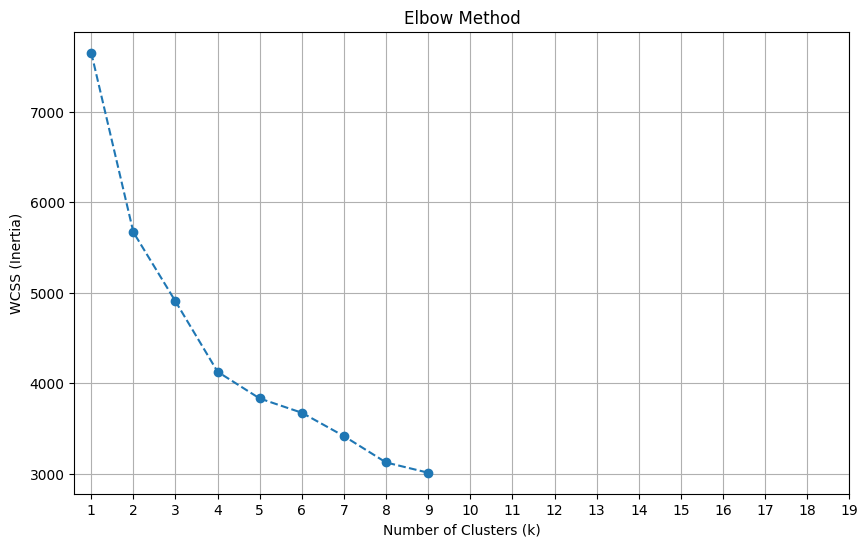

In [51]:
customer_df_addres_scaled = pd.DataFrame(scaler.fit_transform(customer_df_addres), columns=customer_df_addres.columns)
result = []
for rec in range(1, 10):
  kmeans = KMeans(n_clusters=rec, random_state=42)
  kmeans.fit(customer_df_addres_scaled)
  result.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), result, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 20))
plt.grid(True)
plt.show()

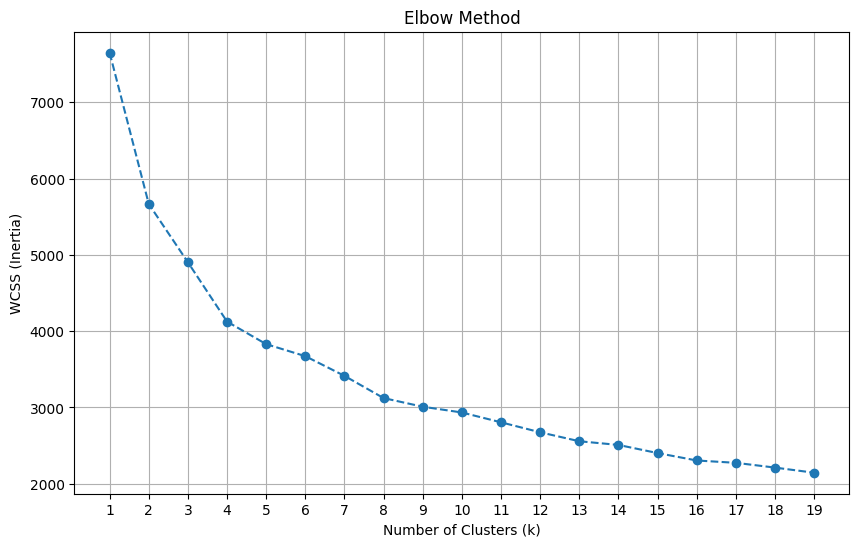

In [50]:
wcss = []
for i in range(1, 20):
    kmeans_elbow = KMeans(n_clusters=i, random_state=42)
    kmeans_elbow.fit(customer_df_addres_scaled)
    wcss.append(kmeans_elbow.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 20))
plt.grid(True)
plt.show()

In [56]:
# having cluster as 4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
kmeans_4.fit(customer_df_addres_scaled)
customer_df_addres['cluster'] = kmeans_4.predict(customer_df_addres_scaled)


In [57]:
customer_df_addres.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,Cluster,cluster
0,41,2,6,19,0.124,1.073,0,6.3,1,0
1,47,1,26,100,4.582,8.218,0,12.8,2,3
2,33,2,10,57,6.111,5.802,1,20.9,2,3
3,29,2,4,19,0.681,0.516,0,6.3,1,0
4,47,1,31,253,9.308,8.908,0,7.2,2,3


In [59]:
# finding the shilout score
silhouette_score(customer_df_addres_scaled, kmeans_4.labels_)


np.float64(0.2762747779960399)